<a href="https://colab.research.google.com/github/SriVarshan733/final-year-project-UH/blob/main/final_year_project_uh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# 1. Force upgrade kagglehub to ensure progress bar support
!pip install --upgrade kagglehub

import kagglehub
import os

print("🚀 Starting download. Sit back, this is a 6 GB dataset!")
print("Look below for the download progress status:")

try:
    # Trigger download with progress tracking enabled implicitly in newer versions
    path = kagglehub.dataset_download("flnny123/mfddmulti-modal-flight-delay-dataset")
    print("\n✅ Success! Dataset files downloaded to:", path)
    print("Contents:", os.listdir(path))
except Exception as e:
    print(f"\n❌ Error encountered: {e}")

🚀 Starting download. Sit back, this is a 6 GB dataset!
Look below for the download progress status:
Download already complete (5607871754 bytes).
Extracting files...

✅ Success! Dataset files downloaded to: /root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4
Contents: ['Aeolus']


In [14]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Set style for high-quality plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

**STEP 1: LOCATE THE FILES IN THE EXTRACTED FOLDER**

In [16]:
base_path = "/root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus"

print("--- Step 1: Navigating Aeolus Subfolders ---")
subfolders = os.listdir(base_path)
print("Available modalities inside Aeolus:", subfolders)

--- Step 1: Navigating Aeolus Subfolders ---
Available modalities inside Aeolus: ['Flight_chain', 'Flight_network', 'Flight_Tab']


In [17]:
# Dynamically locate the Tabular directory
tab_folder_name = [f for f in subfolders if "Tab" in f][0]
tab_path = os.path.join(base_path, tab_folder_name)

# Find all CSV files inside the Tabular directory
csv_files = sorted(glob.glob(os.path.join(tab_path, "*.csv")))
print(f"\nFound {len(csv_files)} splits inside {tab_folder_name}:")
for f in csv_files:
    print(f" - {os.path.basename(f)} ({os.path.getsize(f) / (1024**2):.2f} MB)")


Found 9 splits inside Flight_Tab:
 - flight_with_weather_2016.csv (1467.16 MB)
 - flight_with_weather_2017.csv (1478.04 MB)
 - flight_with_weather_2018.csv (1851.47 MB)
 - flight_with_weather_2019.csv (1898.17 MB)
 - flight_with_weather_2020.csv (1142.37 MB)
 - flight_with_weather_2021.csv (1525.91 MB)
 - flight_with_weather_2022.csv (1700.07 MB)
 - flight_with_weather_2023.csv (1761.85 MB)
 - flight_with_weather_2024.csv (1667.36 MB)


**STEP 2: LOAD A SMART SAMPLE FOR EDA**

In [18]:
print("\n--- Step 2: Loading Data Split for Analysis ---")
# Loading the first file as our EDA target
target_file = csv_files[0]
print(f"Loading data sample from: {os.path.basename(target_file)}")

# To keep Colab fast and light, we read a sample chunk of 200,000 rows
df_sample = pd.read_csv(target_file, nrows=200000)
print(f"Loaded Shape: {df_sample.shape[0]} rows, {df_sample.shape[1]} columns")


--- Step 2: Loading Data Split for Analysis ---
Loading data sample from: flight_with_weather_2016.csv
Loaded Shape: 200000 rows, 34 columns


**STEP 3: INITIAL DATA STRUCTURAL HEALTH CHECK**

In [19]:
print("\n--- Step 3: Dataset Schema Summary ---")
print(df_sample.info())

print("\n--- Missing Value Audit ---")
missing_summary = df_sample.isnull().sum()
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values found!")


--- Step 3: Dataset Schema Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 34 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FL_DATE              200000 non-null  object 
 1   OP_CARRIER           200000 non-null  object 
 2   OP_CARRIER_FL_NUM    200000 non-null  float64
 3   ORIGIN               200000 non-null  object 
 4   DEST                 200000 non-null  object 
 5   CRS_DEP_TIME         200000 non-null  object 
 6   DEP_TIME             200000 non-null  object 
 7   DEP_DELAY            200000 non-null  float64
 8   TAXI_OUT             200000 non-null  float64
 9   WHEELS_OFF           200000 non-null  object 
 10  WHEELS_ON            200000 non-null  object 
 11  TAXI_IN              200000 non-null  float64
 12  CRS_ARR_TIME         200000 non-null  object 
 13  ARR_TIME             200000 non-null  object 
 14  ARR_DELAY            200000 

**STEP 4: DISTRIBUTIONS & CORE QUANTITATIVE EDA**

In [21]:
print("\n--- Step 4: Generating Descriptive Analysis & Plots ---")

# Let's ensure target columns are numeric
if 'ARR_DELAY' in df_sample.columns:
    # 1. Descriptive stats of the delay distributions
    print("\nDelay Field Statistics:")
    print(df_sample[['ARR_DELAY', 'DEP_DELAY']].describe())


--- Step 4: Generating Descriptive Analysis & Plots ---

Delay Field Statistics:
           ARR_DELAY      DEP_DELAY
count  200000.000000  200000.000000
mean        6.741740      10.274850
std        43.068883      39.324859
min      -107.000000     -59.000000
25%       -13.000000      -4.000000
50%        -2.000000      -1.000000
75%        13.000000       8.000000
max      1637.000000    1551.000000


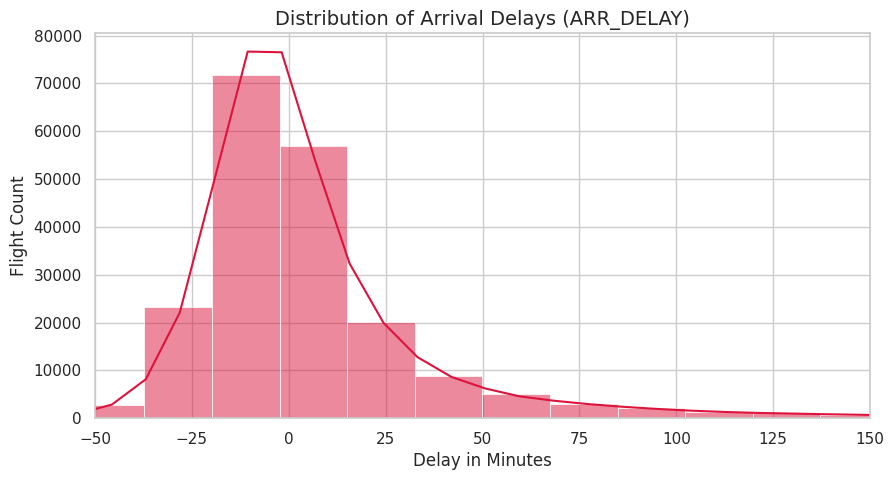

In [23]:
    # 2. Plotting Target Variable (Arrival Delay) Distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(df_sample['ARR_DELAY'], bins=100, kde=True, color='crimson')
    plt.xlim(-50, 150) # Zooming in on the core distribution density
    plt.title("Distribution of Arrival Delays (ARR_DELAY)", fontsize=14)
    plt.xlabel("Delay in Minutes")
    plt.ylabel("Flight Count")
    plt.show()

/tmp/ipykernel_10094/289609281.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sample, x='OP_CARRIER', order=df_sample['OP_CARRIER'].value_counts().index, palette='viridis')


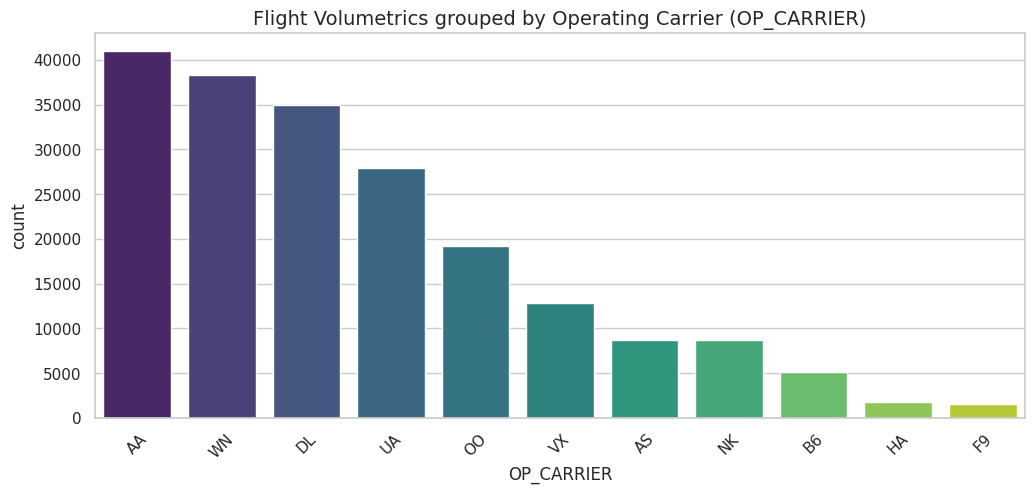

In [24]:
# 3. Categorical Assessment: Top Airlines in this data split
if 'OP_CARRIER' in df_sample.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df_sample, x='OP_CARRIER', order=df_sample['OP_CARRIER'].value_counts().index, palette='viridis')
    plt.title("Flight Volumetrics grouped by Operating Carrier (OP_CARRIER)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

/tmp/ipykernel_10094/2191049378.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sample, x='WSPD_BINS', y='DEP_DELAY', errorbar=None, palette='Blues_d')


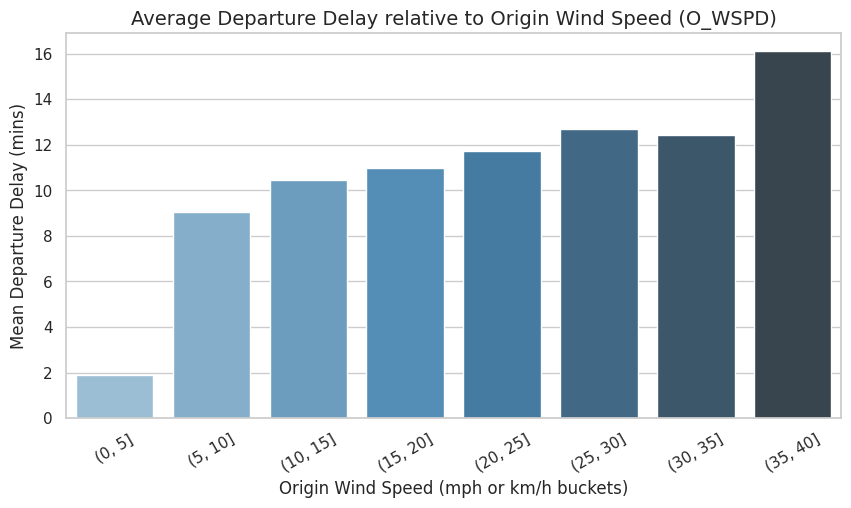

In [25]:
# 4. Spatiotemporal Cross-Analysis: Weather vs Delays
# Let's check how Wind Speed at the Origin airport impacts Departure Delays
if 'O_WSPD' in df_sample.columns and 'DEP_DELAY' in df_sample.columns:
    plt.figure(figsize=(10, 5))
    # Bucketing wind speed into steps to view general profile trends
    df_sample['WSPD_BINS'] = pd.cut(df_sample['O_WSPD'], bins=range(0, 45, 5))
    sns.barplot(data=df_sample, x='WSPD_BINS', y='DEP_DELAY', errorbar=None, palette='Blues_d')
    plt.title("Average Departure Delay relative to Origin Wind Speed (O_WSPD)", fontsize=14)
    plt.xlabel("Origin Wind Speed (mph or km/h buckets)")
    plt.ylabel("Mean Departure Delay (mins)")
    plt.xticks(rotation=30)
    plt.show()